<a href="https://colab.research.google.com/github/Ghanavi2903/APS-LAB/blob/main/binaryclassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix


In [3]:
data=load_breast_cancer()
X=pd.DataFrame(data.data,columns=data.feature_names)
y=pd.Series((data.target==0).astype(int),name="malignant")
print(y.value_counts())
print("feature matrix shape:",X.shape)
print("target shape:",y.shape)
print("class name:",data.target_names)

malignant
0    357
1    212
Name: count, dtype: int64
feature matrix shape: (569, 30)
target shape: (569,)
class name: ['malignant' 'benign']


In [4]:
class_counts=y.value_counts().sort_index()
class_distribution=pd.DataFrame({"class":data.target_names,"count":class_counts.values,"Probablity":class_counts.values /len(y) })
print(class_distribution)


       class  count  Probablity
0  malignant    357    0.627417
1     benign    212    0.372583


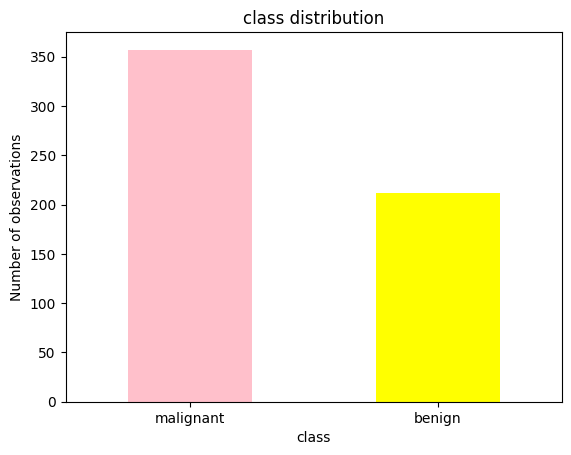

In [5]:
class_distribution.plot(x="class",y="count",kind="bar",legend=False,color=["pink","yellow"])
plt.ylabel("Number of observations")
plt.title("class distribution")
plt.xticks(rotation=0)
plt.show()

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)
print("training size:",len(y_train))
print("testing size:",len(y_test))
print("\ntraining proportions")
print(y_train.value_counts(normalize=True).sort_index())
print("\ntesting proportions")
print(y_test.value_counts(normalize=True).sort_index())



training size: 455
testing size: 114

training proportions
malignant
0    0.626374
1    0.373626
Name: proportion, dtype: float64

testing proportions
malignant
0    0.631579
1    0.368421
Name: proportion, dtype: float64


In [7]:
model=make_pipeline(StandardScaler(),LogisticRegression(max_iter=1000))
model.fit(X_train,y_train)


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression(max_iter=1000))])

In [8]:
probablities=model.predict_proba(X_test)
print(probablities[:5])

[[9.99635432e-01 3.64568116e-04]
 [1.07465986e-08 9.99999989e-01]
 [9.57432053e-01 4.25679471e-02]
 [4.23812678e-01 5.76187322e-01]
 [4.90844511e-01 5.09155489e-01]]


In [9]:
print(probablities[:5].sum(axis=1))

[1. 1. 1. 1. 1.]


In [10]:
results=pd.DataFrame({"actual_class":y_test.values,"P_malignent":probablities[:,0],"P_benign":probablities[:,1]})
print(results.head(10))

   actual_class   P_malignent  P_benign
0             0  9.996354e-01  0.000365
1             1  1.074660e-08  1.000000
2             0  9.574321e-01  0.042568
3             1  4.238127e-01  0.576187
4             0  4.908445e-01  0.509155
5             0  9.993840e-01  0.000616
6             1  2.384659e-01  0.761534
7             0  9.989878e-01  0.001012
8             0  9.994313e-01  0.000569
9             0  9.892324e-01  0.010768


In [11]:
results["actual_label"]=results["actual_class"].map({ 1:"benign",0:"malignent"})
print(results[["actual_label","P_malignent","P_benign"]].head(10))

  actual_label   P_malignent  P_benign
0    malignent  9.996354e-01  0.000365
1       benign  1.074660e-08  1.000000
2    malignent  9.574321e-01  0.042568
3       benign  4.238127e-01  0.576187
4    malignent  4.908445e-01  0.509155
5    malignent  9.993840e-01  0.000616
6       benign  2.384659e-01  0.761534
7    malignent  9.989878e-01  0.001012
8    malignent  9.994313e-01  0.000569
9    malignent  9.892324e-01  0.010768


In [13]:
threshold=0.5
results["Predicted_malignent"]=(results["P_malignent"]>=threshold).astype(int)
results["Predicted_label"]=results["Predicted_malignent"].map({1:"malignent",0:"benign"})
print(results[["actual_label","Predicted_label","P_malignent"]].head(10))

  actual_label Predicted_label   P_malignent
0    malignent       malignent  9.996354e-01
1       benign          benign  1.074660e-08
2    malignent       malignent  9.574321e-01
3       benign          benign  4.238127e-01
4    malignent          benign  4.908445e-01
5    malignent       malignent  9.993840e-01
6       benign          benign  2.384659e-01
7    malignent       malignent  9.989878e-01
8    malignent       malignent  9.994313e-01
9    malignent       malignent  9.892324e-01


In [14]:
for threshold in [0.30,0.50,0.70]:
  predictions=(results["P_malignent"]>=threshold).astype(int)
  print(f"Threshold ={threshold}:" f"predicted malignent cases={predictions.sum()}")


Threshold =0.3:predicted malignent cases=76
Threshold =0.5:predicted malignent cases=74
Threshold =0.7:predicted malignent cases=72


In [23]:
actual_malignent=(y_test.values==0).astype(int)
for threshold in [0.30,0.50,0.70]:
  predictions=(probablities[:,0]>=threshold).astype(int)
  cm=confusion_matrix(actual_malignent,predictions)
  print(f"\nThreshold={threshold}")
  print(cm)


Threshold=0.3
[[38  4]
 [ 0 72]]

Threshold=0.5
[[39  3]
 [ 1 71]]

Threshold=0.7
[[41  1]
 [ 1 71]]


In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

threshold_results = []

for threshold in [0.10,0.30, 0.50, 0.70,0.90]:
    predictions = (probablities[:, 0] >= threshold).astype(int)
    tn,fp,fn,tp=confusion_matrix(actual_malignent,predictions,labels=[0,1]).ravel()
    threshold_results.append({
        "Threshold": threshold,
        "True Negatives (tn)": tn,
        "False Positives (fp)": fp,
        "False Negatives (fn)": fn,
        "True Positives (tp)": tp,
        "Accuracy": accuracy_score(actual_malignent, predictions),
        "Precision": precision_score(actual_malignent, predictions),
        "Recall": recall_score(actual_malignent, predictions),
        "F1 Score": f1_score(actual_malignent, predictions)
    })

threshold_table = pd.DataFrame(threshold_results)

display(threshold_table)

,Threshold,True Negatives (tn),False Positives (fp),False Negatives (fn),True Positives (tp),Accuracy,Precision,Recall,F1 Score
0,0.1,33,9,0,72,0.921053,0.888889,1.000000,0.941176
1,0.3,38,4,0,72,0.964912,0.947368,1.000000,0.972973
2,0.5,39,3,1,71,0.964912,0.959459,0.986111,0.972603
3,0.7,41,1,1,71,0.982456,0.986111,0.986111,0.986111
4,0.9,41,1,5,67,0.947368,0.985294,0.930556,0.957143


NameError: name 'probabilities' is not defined